# Comparative Annotation of Mixed Bird Vocalizations Using Raven Lite 

This notebook documents a bioacoustic annotation project designed to demonstrate how basic temporal and spectral characteristics differ across bird species. Mixed-species recordings were obtained from xeno-canto.org and manually annotated to identify song vocalizations from three target species: red-winged blackbirds (Agelaius phoeniceus), marsh wrens (Cistothorus palustris), and northern cardinals (Cardinalis cardinalis).

Due to differences in recording parameters, each audio file was annotated individually, with annotation tables exported per recording and later combined for analysis. The notebook summarizes the annotated selections and presents comparative descriptive statistics and visualizations of song duration and frequency range across the three species. Only clearly identifiable song vocalizations were annotated; call notes and ambiguous sounds were excluded.

## Species Codes
The following shorthand codes are used throughout this notebook to label annotated song vocalizations:

- **RWBL** — Red-winged Blackbird (*Agelaius phoeniceus*)
- **MAWR** — Marsh Wren (*Cistothorus palustris*)
- **NOCA** — Northern Cardinal (*Cardinalis cardinalis*)

## Combine the 8 Files

In [1]:
# Imports needed for project
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# List all CSV files in Data/Annotations
files = glob.glob('../Data/Annotations_raw/*.csv')

# Combine all CSVs
df_list = [pd.read_csv(f) for f in files]
df_master = pd.concat(df_list, ignore_index=True)

# Save combined CSV in the same folder
df_master.to_csv('../Data/Annotations_combined/mixed_bird_song_annotations_master.csv', index=False)

print("Combined CSV created. Number of rows:", len(df_master))

Combined CSV created. Number of rows: 102


## Create Needed Columns For Analysis

In [3]:
data = df_master.copy()
print(data.head(5))

   Selection           View  Channel  Begin Time (s)  End Time (s)  \
0          1  Spectrogram 1        1        1.498321      2.762862   
1          2  Spectrogram 1        1        2.837247      3.676732   
2          3  Spectrogram 1        1        5.738252      6.535231   
3          4  Spectrogram 1        1        8.457677      9.350293   
4          5  Spectrogram 1        1       10.338548     11.220539   

   Low Freq (Hz)  High Freq (Hz)  Delta Time (s)  Delta Freq (Hz)  \
0       1046.309        3061.424          1.2645         2015.114   
1       1123.814        3255.185          0.8395         2131.371   
2       1240.070        2945.167          0.7970         1705.097   
3       1046.309        2790.158          0.8926         1743.849   
4       1123.814        3022.671          0.8820         1898.858   

   Avg Power Density (dB FS/Hz) Annotation  
0                        -28.20       RWBL  
1                        -41.54       RWBL  
2                        -48.

In [4]:
#### Convert Hz columns to kHz for readability
data['Low Freq (kHz)'] = data['Low Freq (Hz)'] * 0.001
data['High Freq (kHz)'] = data['High Freq (Hz)'] * 0.001
data['Delta Freq (kHz)'] = data['Delta Freq (Hz)'] * 0.001

In [5]:
# Create a new column 'Song_ID' with numbers from 1 to 103 for reference in Plots
data['Song_ID'] = range(1, 103)
print(data.head())

   Selection           View  Channel  Begin Time (s)  End Time (s)  \
0          1  Spectrogram 1        1        1.498321      2.762862   
1          2  Spectrogram 1        1        2.837247      3.676732   
2          3  Spectrogram 1        1        5.738252      6.535231   
3          4  Spectrogram 1        1        8.457677      9.350293   
4          5  Spectrogram 1        1       10.338548     11.220539   

   Low Freq (Hz)  High Freq (Hz)  Delta Time (s)  Delta Freq (Hz)  \
0       1046.309        3061.424          1.2645         2015.114   
1       1123.814        3255.185          0.8395         2131.371   
2       1240.070        2945.167          0.7970         1705.097   
3       1046.309        2790.158          0.8926         1743.849   
4       1123.814        3022.671          0.8820         1898.858   

   Avg Power Density (dB FS/Hz) Annotation  Low Freq (kHz)  High Freq (kHz)  \
0                        -28.20       RWBL        1.046309         3.061424   
1     

In [6]:
# Drop unnecessary columns
data = data.drop(columns=['Selection', 'View', 'Channel'])

# Reorder columns for readability
data = data[['Song_ID','Annotation', 'Begin Time (s)', 'End Time (s)', 'Low Freq (kHz)', 'High Freq (kHz)', 'Delta Time (s)', 'Delta Freq (kHz)']]

# Save cleaned version
data.to_csv('../Data/Annotations_combined/mixed_bird_song_annotations_master_clean.csv', index=False)
print(data.head(3))

   Song_ID Annotation  Begin Time (s)  End Time (s)  Low Freq (kHz)  \
0        1       RWBL        1.498321      2.762862        1.046309   
1        2       RWBL        2.837247      3.676732        1.123814   
2        3       RWBL        5.738252      6.535231        1.240070   

   High Freq (kHz)  Delta Time (s)  Delta Freq (kHz)  
0         3.061424          1.2645          2.015114  
1         3.255185          0.8395          2.131371  
2         2.945167          0.7970          1.705097  


## Data Analysis

### Summary Statistics
Basic summary statistics were calculated to characterize the temporal and spectral properties of annotated song selections and compared across species prior to visualization.

In [7]:
group = data.groupby('Annotation') 
count = group.size().rename('count') 
others = group[['Delta Time (s)', 'Low Freq (kHz)', 'High Freq (kHz)', 'Delta Freq (kHz)']].agg(['mean']) 
others.columns = ['_'.join(col) for col in others.columns] 
stats = pd.concat([count, others], axis=1).round(2)
print(stats)

            count  Delta Time (s)_mean  Low Freq (kHz)_mean  \
Annotation                                                    
MAWR           33                 1.44                 1.95   
NOCA           17                 2.00                 1.36   
RWBL           52                 0.95                 1.53   

            High Freq (kHz)_mean  Delta Freq (kHz)_mean  
Annotation                                               
MAWR                        4.25                   2.30  
NOCA                        4.47                   3.11  
RWBL                        3.88                   2.35  


### Create a Comparative Histogram of Song Durations

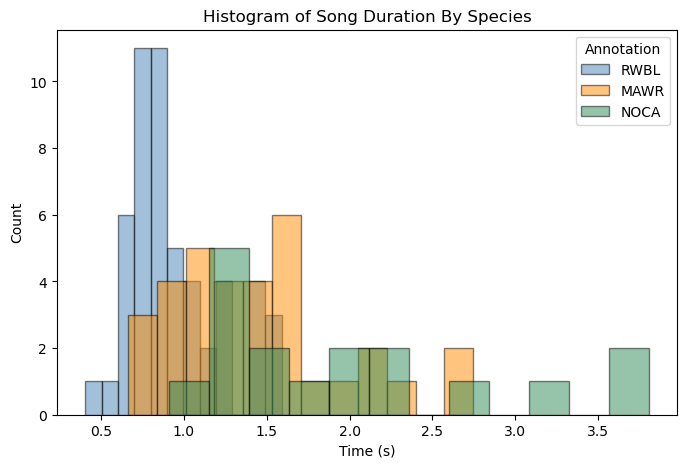

In [8]:
# Pick colors for your three categories 
colors = ['steelblue', 'darkorange', 'seagreen'] 
# Create the figure 
plt.figure(figsize=(8, 5)) 
# Loop through each annotation category 
for (label, color) in zip(data['Annotation'].unique(), colors): 
    subset = data[data['Annotation'] == label]['Delta Time (s)'] 
    plt.hist(subset, bins=12, alpha=0.5, label=label, color=color, edgecolor='black') 
# Labels and title 
plt.title('Histogram of Song Duration By Species') 
plt.xlabel('Time (s)') 
plt.ylabel('Count') 
plt.legend(title='Annotation') 
plt.show()

Song duration distributions differed across species, with red-winged blackbird songs showing shorter, more tightly clustered durations, while marsh wrens and northern cardinals exhibited longer and more variable song lengths.

### Create A Comparative Frequency Range Band Plot

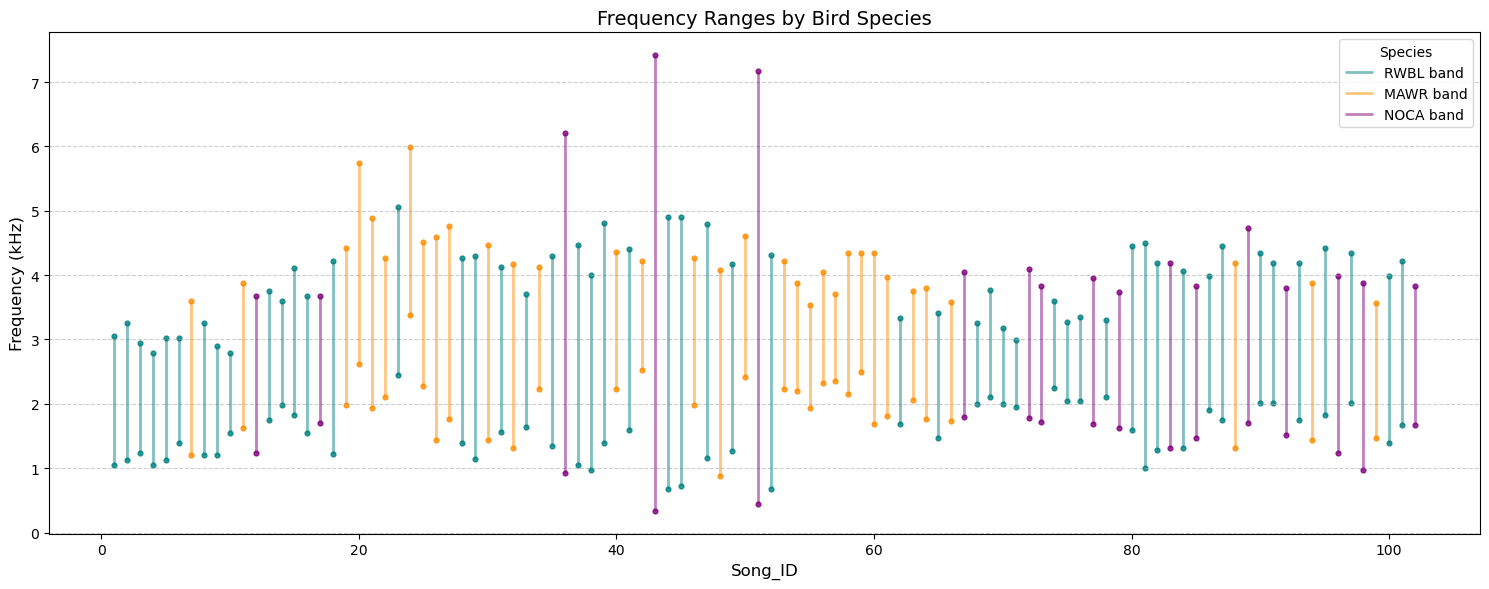

In [9]:
# Pick distinct colors for each species
colors = ['teal', 'darkorange', 'purple']

plt.figure(figsize=(15, 6))

for (label, color) in zip(data['Annotation'].unique(), colors):
    subset = data[data['Annotation'] == label]

    # Vertical frequency bands
    plt.vlines(
        x=subset['Song_ID'],
        ymin=subset['Low Freq (kHz)'],
        ymax=subset['High Freq (kHz)'],
        colors=color,
        alpha=0.5,
        linewidth=2,
        label=f'{label} band'
    )

    # Dots at bottom and top
    plt.scatter(
        subset['Song_ID'],
        subset['Low Freq (kHz)'],
        color=color,
        s=12,
        alpha=0.8
    )
    plt.scatter(
        subset['Song_ID'],
        subset['High Freq (kHz)'],
        color=color,
        s=12,
        alpha=0.8
    )

# Formatting
plt.title('Frequency Ranges by Bird Species', fontsize=14)
plt.xlabel('Song_ID', fontsize=12)
plt.ylabel('Frequency (kHz)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Species')

plt.tight_layout()
plt.show()


Frequency range band plots illustrate the variation in low and high frequency bounds for individual annotated songs. While all three species occupy overlapping frequency ranges, differences in the spread and consistency of these bands are apparent, with northern cardinal songs showing the widest frequency ranges and greater variability compared to red-winged blackbirds and marsh wrens.

### Create a Scatter Plot Comparing Song Duration To Frequency Range 

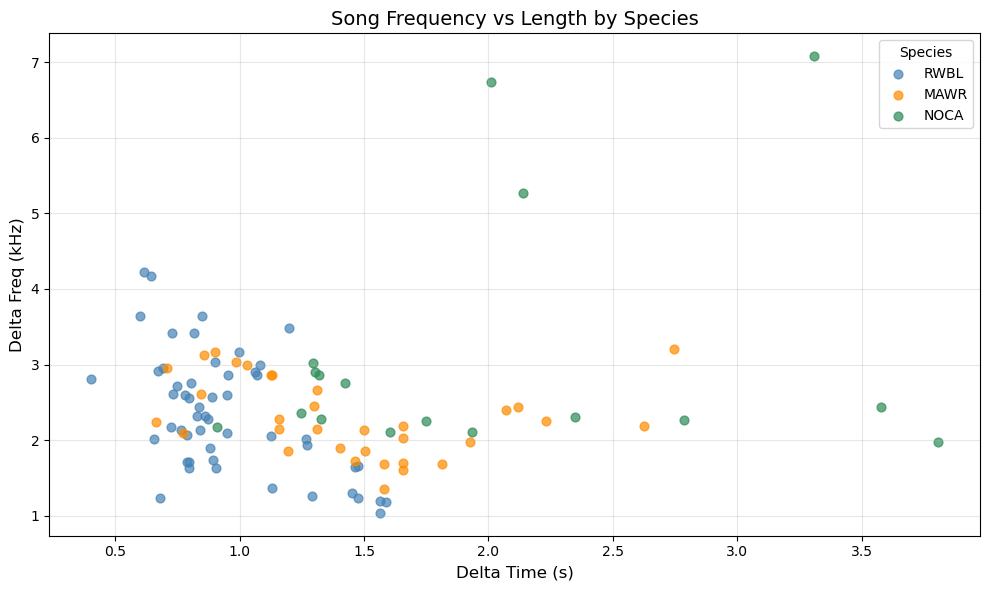

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

colors = ['steelblue', 'darkorange', 'seagreen']

for label, color in zip(data['Annotation'].unique(), colors):
    subset = data[data['Annotation'] == label]
    plt.scatter(
        subset['Delta Time (s)'],
        subset['Delta Freq (kHz)'],
        color=color,
        alpha=0.7,
        s=40,
        label=label
    )

plt.title('Song Frequency vs Length by Species', fontsize=14)
plt.xlabel('Delta Time (s)', fontsize=12)
plt.ylabel('Delta Freq (kHz)', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(title='Species')

plt.tight_layout()
plt.show()


A scatter plot of song duration versus frequency range illustrates how temporal and spectral characteristics vary jointly across species. Red-winged blackbird songs tend to cluster at shorter durations with moderate frequency ranges, while northern cardinal songs show longer durations and greater frequency variability. Marsh wren songs occupy an intermediate region, with some overlap across species.